<a href="https://colab.research.google.com/github/Aashkaushx/Excel-analysis-platform/blob/main/ML_Project_new1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.style.use('fivethirtyeight')
%matplotlib inline

In [18]:
import yfinance as yf
import datetime as dt

#using it we can download data from yfinance website
stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2026, 5, 1)

df = yf.download(stock, start, end)

/tmp/ipykernel_3306/3355037121.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [19]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896240,33.629606,25.537001,27.579348,855215656
2007-10-08,29.314556,31.940428,29.130284,31.940428,126671715
2007-10-09,31.310850,31.587257,27.748262,29.329927,116725709
2007-10-10,31.602610,32.247562,31.326203,32.124712,67931378
2007-10-11,35.134495,36.854366,31.326212,36.854366,106320954


In [20]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2026-04-20,319.700012,323.049988,315.549988,319.000000,10955277
2026-04-21,319.350006,322.000000,318.000000,318.950012,8342335
2026-04-22,319.750000,322.000000,316.000000,319.750000,7112538
2026-04-23,319.149994,321.850006,318.049988,320.000000,7294961
2026-04-24,316.399994,317.899994,314.500000,316.000000,9980241


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4573 entries, 2007-10-05 to 2026-04-24
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4573 non-null   float64
 1   (High, POWERGRID.NS)    4573 non-null   float64
 2   (Low, POWERGRID.NS)     4573 non-null   float64
 3   (Open, POWERGRID.NS)    4573 non-null   float64
 4   (Volume, POWERGRID.NS)  4573 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 214.4 KB


In [22]:
df.shape

(4573, 5)

In [23]:
df.isnull().sum()

,,0
Price,Ticker,
Close,POWERGRID.NS,0
High,POWERGRID.NS,0
Low,POWERGRID.NS,0
Open,POWERGRID.NS,0
Volume,POWERGRID.NS,0


In [24]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4573.000000,4573.000000,4573.000000,4573.000000,4.573000e+03
mean,92.608580,93.765453,91.462190,92.649233,1.199077e+07
std,81.741809,82.639777,80.806260,81.743402,1.987417e+07
min,18.038851,19.282909,16.172763,19.189604,0.000000e+00
25%,35.277245,35.817719,34.793638,35.310003,5.025753e+06
50%,65.519417,66.472301,64.648423,65.593351,8.691695e+06
75%,104.751411,106.423001,103.709330,104.535217,1.391237e+07
max,344.843262,345.598106,337.058457,343.522181,8.552157e+08


In [25]:
df = df.reset_index()

In [26]:
df.columns


MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [27]:
df.to_csv("powergrid.csv")

In [28]:
data01 = pd.read_csv("powergrid.csv")

In [29]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896240234375,33.62960604727621,25.53700130653391,27.579347988281896,855215656
2,1,2007-10-08,29.314556121826172,31.940427540707997,29.13028363942551,31.940427540707997,126671715
3,2,2007-10-09,31.310850143432617,31.587256941567578,27.748262063093062,29.329927119909353,116725709
4,3,2007-10-10,31.602609634399414,32.24756153152194,31.326202868654203,32.12471246013357,67931378


In [30]:
# candlesticks = df.plot
#type of pie chart used in technical analysis in stock
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'],
                                     high = data01['High'],
                                     low = data01['Low'],
                                     close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [31]:
df = df.drop(['Date'], axis = 1)
df.head()

/tmp/ipykernel_3306/3502562368.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896240,33.629606,25.537001,27.579348,855215656
1,29.314556,31.940428,29.130284,31.940428,126671715
2,31.310850,31.587257,27.748262,29.329927,116725709
3,31.602610,32.247562,31.326203,32.124712,67931378
4,35.134495,36.854366,31.326212,36.854366,106320954


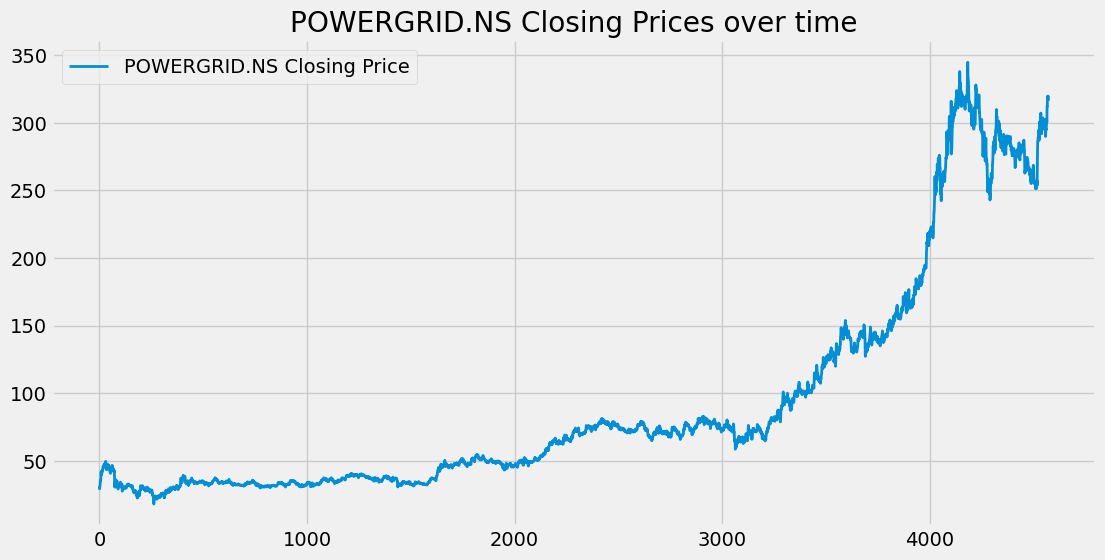

In [32]:
# creating one plot so that we can check the closing price over timevalue of stock
plt.figure(figsize = (12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth= 2)
plt.title(f'{stock} Closing Prices over time')
plt.legend()
plt.show()

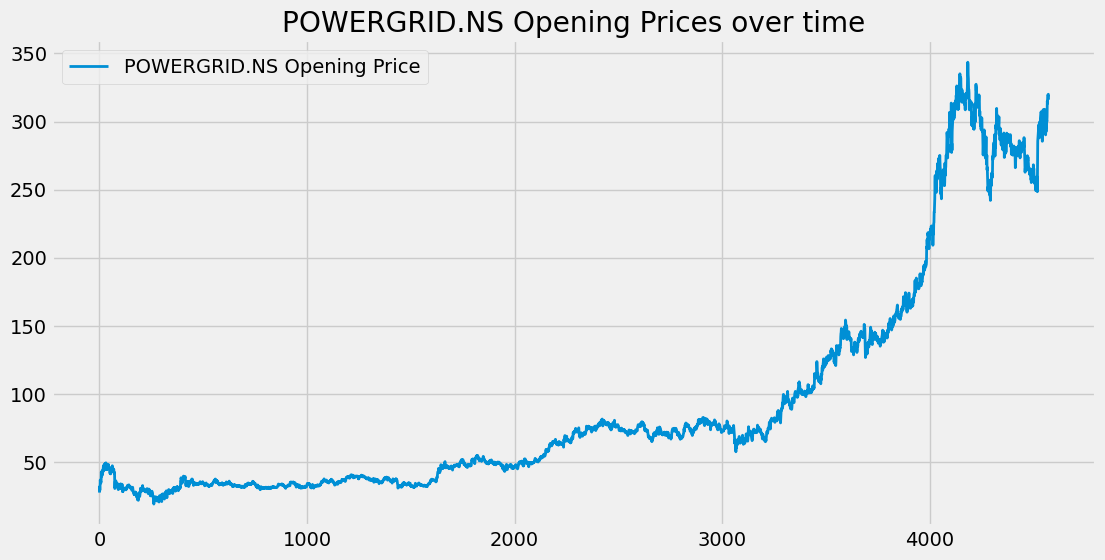

In [33]:
plt.figure(figsize = (12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth= 2)
plt.title(f'{stock} Opening Prices over time')
plt.legend()
plt.show()

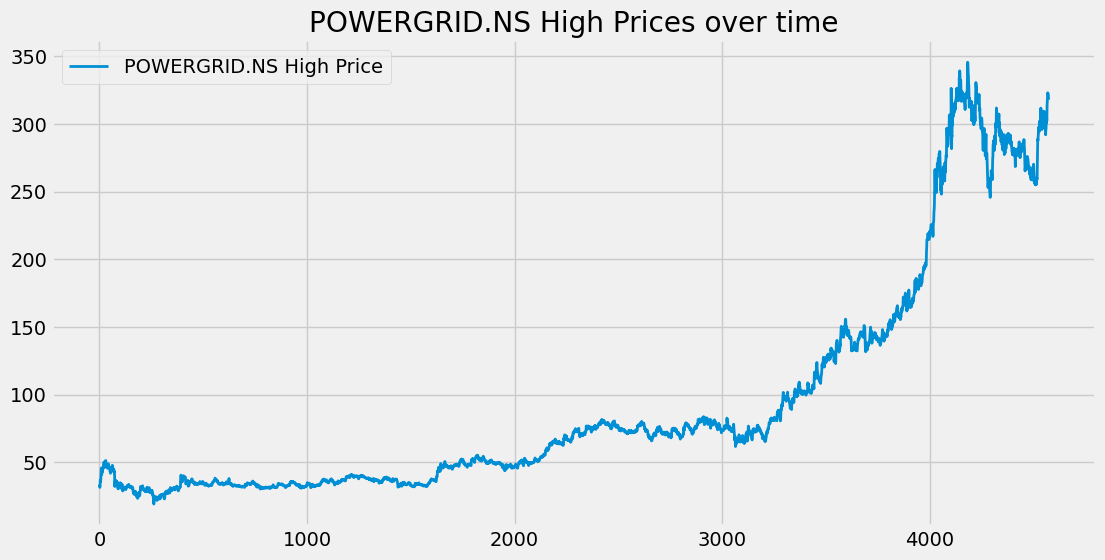

In [34]:
plt.figure(figsize = (12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth= 2)
plt.title(f'{stock} High Prices over time')
plt.legend()
plt.show()

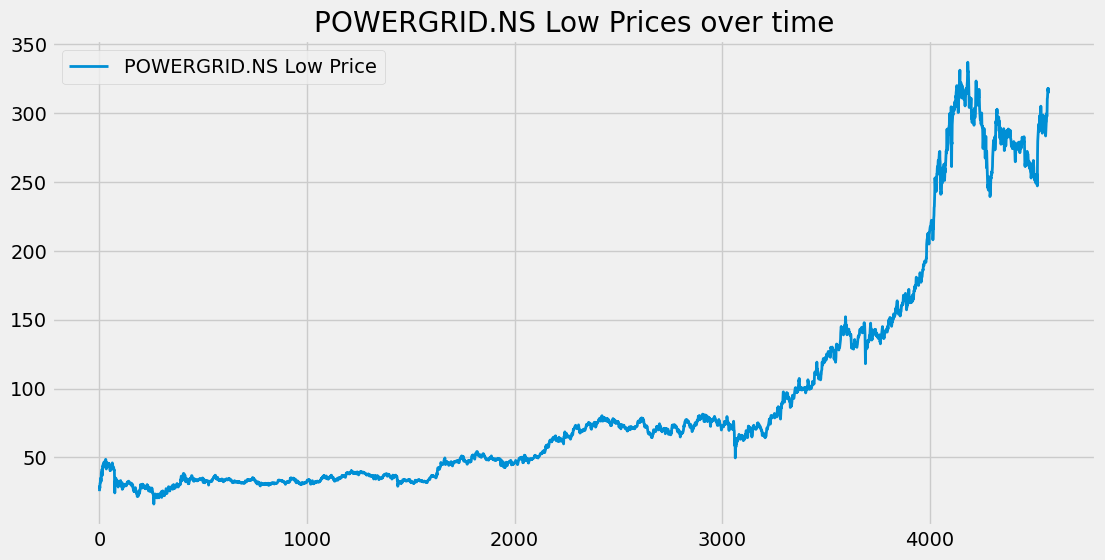

In [35]:
plt.figure(figsize = (12, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth= 2)
plt.title(f'{stock} Low Prices over time')
plt.legend()
plt.show()

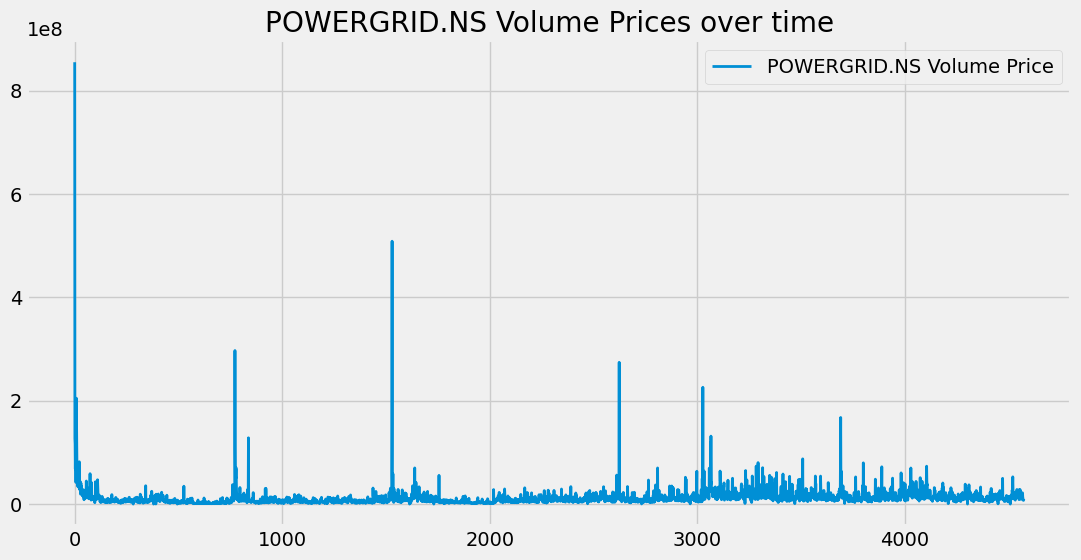

In [36]:
plt.figure(figsize = (12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume Price', linewidth= 2)
plt.title(f'{stock} Volume Prices over time')
plt.legend()
plt.show()

In [37]:
# Moving Average and exponential moving average
# they both are the technique for pridiction
# by it u can pridict next day pridiction
# [10, 20, 30, 40, 50, 60, 70, 780, 90]
# moving average for last 5 days

temp_data= [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[0:5])/5)


30.0


In [38]:
import pandas as pd
df01 = pd.DataFrame(temp_data)



In [39]:
df01.rolling(5).mean()
# calculate moving average for each row we use rolling

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [41]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4568,279.646078
4569,280.094396
4570,280.564515
4571,281.051872


In [43]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4568,279.420149
4569,279.568003
4570,279.714711
4571,279.869797


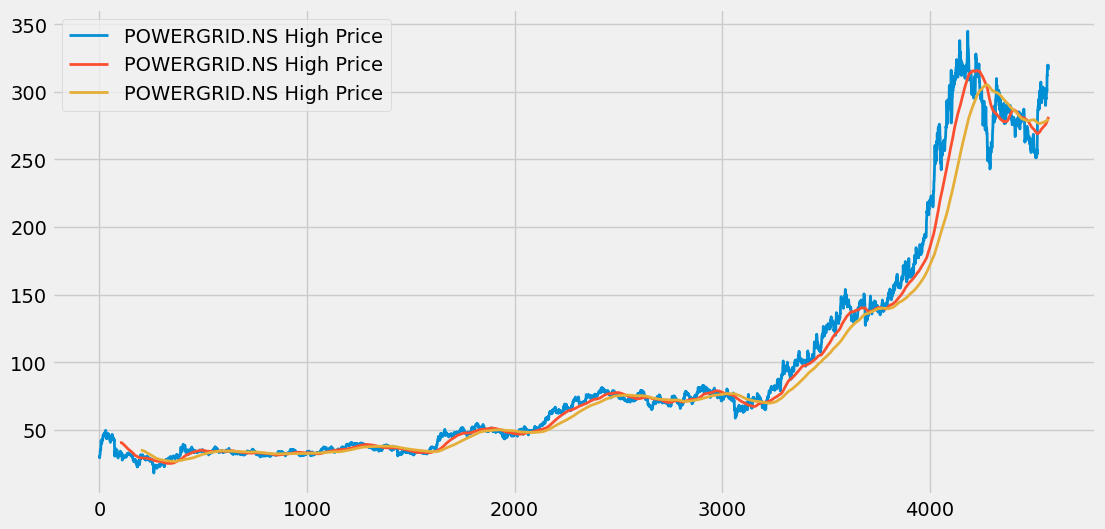

In [45]:
plt.figure(figsize = (12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth= 2)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth= 2)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth= 2)
plt.legend()
plt.show()
# this is the base trend and ma according to trend

In [46]:
# by using ewm u can calculate exponential moving average
ema100 = df.Close.ewm(span=100, adjust=False).mean()

In [47]:
ema200 = df.Close.ewm(span=200, adjust=False).mean()

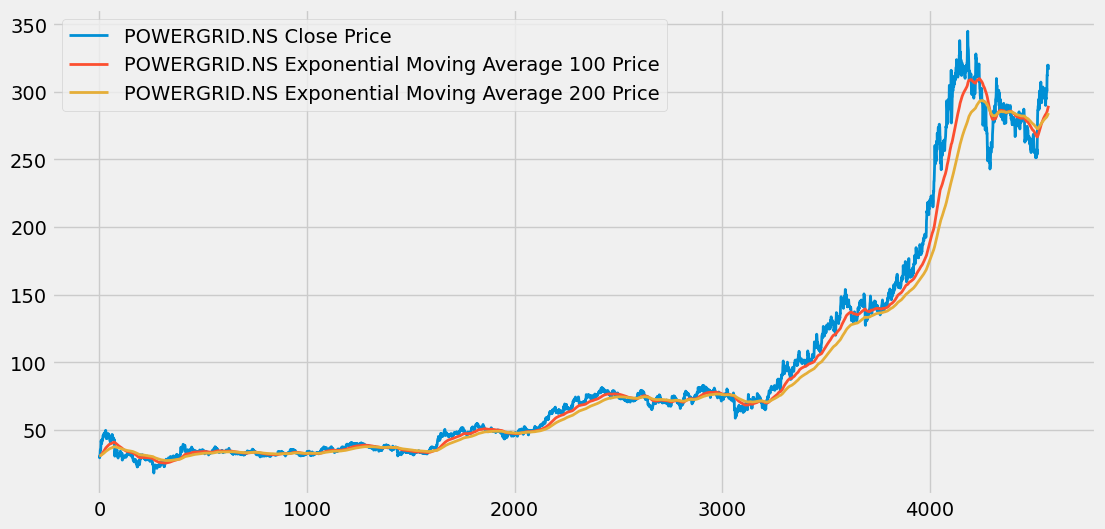

In [50]:
plt.figure(figsize = (12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth= 2)
plt.plot(ema100, label = f'{stock} Exponential Moving Average 100 Price', linewidth= 2)
plt.plot(ema200, label = f'{stock} Exponential Moving Average 200 Price', linewidth= 2)
plt.legend()
plt.show()

In [51]:
# we are using LSTM Intead of RNN because lstm work well with the large dataset because it has large memeory to store data than RNN
# training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [52]:
data_training.shape

(3201, 1)

In [53]:
data_testing.shape

(1372, 1)

In [54]:
# passing this data into min max escala beacuse it data shouldnm't continous
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [55]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.1980861 ],
       [0.17371804],
       [0.20447374],
       ...,
       [0.77701529],
       [0.76579936],
       [0.76804253]])

In [56]:
x_train = [] #feature
y_train = [] #target

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [57]:
x_train.shape

(3101, 100, 1)

In [58]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [ ]:
# LSTM Input -> 3D Array (batch_size, time_steps, seq_len)
# LSTM 2D OR 3D
# 2D -> (batch_size, units)
# 3D -> (batch_size, time_steps, units)

In [59]:
model = Sequential()

model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [60]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# model training started
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 35s 288ms/step - loss: 0.0431
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 47s 353ms/step - loss: 0.0109
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 283ms/step - loss: 0.0086
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 284ms/step - loss: 0.0085
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 48s 357ms/step - loss: 0.0079
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 30s 307ms/step - loss: 0.0074
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 345ms/step - loss: 0.0068
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 287ms/step - loss: 0.0064
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 30s 312ms/step - loss: 0.0063
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 49s 395ms/step - loss: 0.0058
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - loss: 0.0048
Epoch 12/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 291ms/step - loss: 0.0052
Epoch 13/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 29s 298ms/step - loss: 0.0048
Epoch 14/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 371ms/step - loss: 0.0047
Epoch 15/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 

In [64]:
past_100_days = data_training.tail(100)

In [70]:
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)

In [71]:
final_df.head()

Ticker,POWERGRID.NS
0,62.832485
1,64.276207
2,64.438889
3,64.621902
4,63.381504


In [73]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.        ],
       [0.00511939],
       [0.00569625],
       ...,
       [0.9110202 ],
       [0.9088926 ],
       [0.8991412 ]])

In [74]:
x_test = [] #feature
y_test = [] #target

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [75]:
x_test.shape

(1372, 100, 1)

In [76]:
y_predicted = model.predict(x_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step


In [77]:
y_predicted.shape

(1372, 1)

In [78]:
scaler.scale_

array([0.00354596])

In [79]:
scaler_factor = 1/0.00354596
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

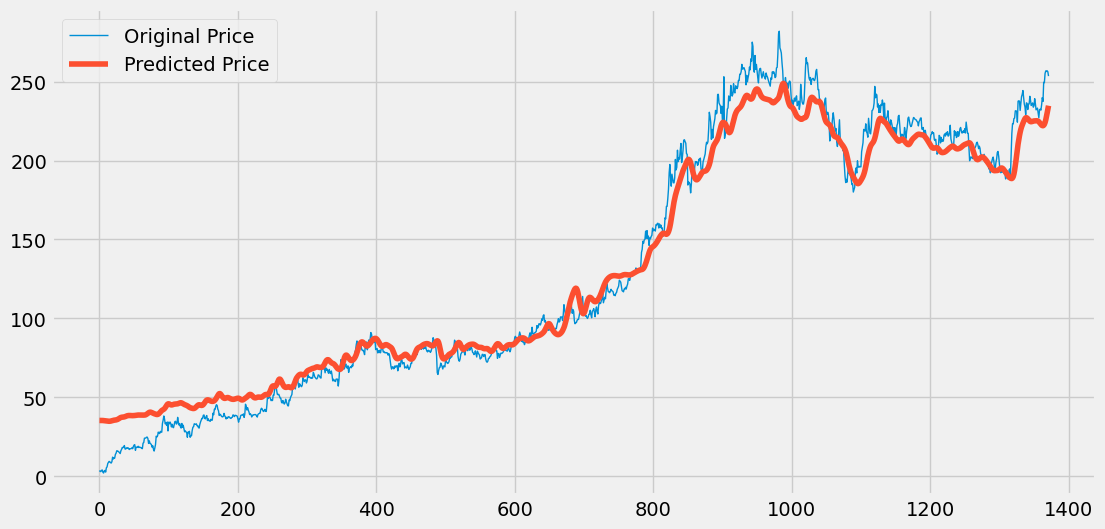

In [85]:
plt.figure(figsize = (12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label =  'Predicted Price')
plt.legend()
plt.show()

In [83]:
model.save('stock_dl_model.h5')